# Notebook 4: Evaluation

Loads the trained policies from Notebook 3 (Configs A–D, 5 seeds each) and evaluates
them on a fresh, held-out 7-day test episode.

Computes: Total Energy Cost (TEC), Total Carbon Emissions (TCE), Grid Stability Index
(GSI), Reward Signal Variance (RSV), and Hypervolume Indicator (HVI).

Also runs the Human-in-the-Loop evaluation (Report Section 3.4): a mid-episode operator
priority switch (Economy → Sustainability) applied to the trained Configuration D policy.

In [22]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.distributions import Categorical
from pathlib import Path

In [24]:
#Loading environment, data, and calibrated reward norms.

from microgrid_env import (
    MicrogridEnv, AGENTS, get_electricity_price, get_carbon_intensity,
    calibrate_reward_norms, df
)

print(df[["building_a", "building_b", "solar"]].describe())

stats = calibrate_reward_norms(lambda: MicrogridEnv(data=df, episode_length=24))
COST_NORM = stats["raw_cost"]["p90"]
EMISSIONS_NORM = stats["raw_emissions"]["p90"]


        building_a   building_b        solar
count  8575.000000  8575.000000  8575.000000
mean      0.508046     0.565472     0.213844
std       0.100270     0.088379     0.323527
min       0.220238     0.095745     0.000000
25%       0.435952     0.500000     0.000620
50%       0.501428     0.569149     0.001859
75%       0.574404     0.630320     0.373606
max       1.000000     1.000000     1.000000
raw_cost: p50=0.0474  p90=0.1436  p99=0.2616  max=0.3691
raw_emissions: p50=0.3120  p90=1.0563  p99=1.3482  max=1.8432
deviation: p50=0.6593  p90=0.9605  p99=1.1086  max=1.2714


In [25]:
PROJ_DIR = Path(r"C:\Users\prish\building-data-genome-project-2")
PROCESSED_DIR = PROJ_DIR / "data" / "processed"
DATA_FILE = PROCESSED_DIR / "bdg2_clean.csv"

RESULTS_DIR = PROJ_DIR / "results"
all_results = torch.load(RESULTS_DIR / "training_results.pt", weights_only=False)

print("Loaded", len(all_results), "trained runs")
print("Configs:", sorted(set(r["config"] for r in all_results)))
print("Seeds per config:", sorted(set(r["seed"] for r in all_results)))

Loaded 20 trained runs
Configs: ['A_fixed_equal', 'B_fixed_tuned', 'C_discrete_adaptive', 'D_amorm_continuous']
Seeds per config: [0, 1, 2, 3, 4]


In [26]:
class Actor(nn.Module):
    def __init__(self, obs_dim=11, action_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    def forward(self, obs):
        return Categorical(logits=self.net(obs))

class Critic(nn.Module):
    def __init__(self, state_dim=13, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


def load_policy(result, agents, device="cpu"):
    """Rebuilds actor networks from a saved training run's state_dicts."""
    actors = {}
    for agent in agents:
        actor = Actor().to(device)
        actor.load_state_dict(result["actors_state_dict"][agent])
        actor.eval()
        actors[agent] = actor
    return actors

Training uses a random episode start every time, by design. 

Evaluation needs the opposite: every configuration and seed must be tested on the exact same 168-hour window, so differences in results reflect policy quality, not which week each one happened to be tested on.

In [27]:
TEST_EPISODE_LENGTH = 168   # 7 days x 24 hours, per Report Section 3.4

def make_test_env(start_step=None):
    """
    Builds an environment fixed to a single held-out 7-day window, using the
    SAME calibrated reward norms as training, so every policy is evaluated
    on identical, unseen conditions and scored the same way it was trained.
    """
    env = MicrogridEnv(
        data=df, episode_length=TEST_EPISODE_LENGTH,
        cost_norm=COST_NORM, emissions_norm=EMISSIONS_NORM
    )
    if start_step is None:
        # Fixed, deterministic test window — NOT randomly resampled like training.
        start_step = len(df) - TEST_EPISODE_LENGTH - 1
    env.episode_start = start_step
    env.current_step = start_step
    return env

In [28]:
def run_evaluation_episode(env, actors, weight_fn, deterministic=True, device="cpu"):
    """
    Runs one full episode with a trained policy (no exploration noise) and
    records everything needed to compute TEC, TCE, GSI.
    """
    obs, _ = env.reset()
    env.current_step = env.episode_start   # reset() re-randomizes; force back to test window
    env.weights = np.array([1/3, 1/3, 1/3], dtype=np.float32)
    obs = env._get_observations()

    prev_L_holder = [None]
    history = []
    done = False

    while not done:
        actions = {}
        for agent in env.possible_agents:
            obs_tensor = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
            dist = actors[agent](obs_tensor)
            action = dist.probs.argmax() if deterministic else dist.sample()
            actions[agent] = int(action.item())

        if weight_fn is not None:
            if weight_fn.__name__ == "weights_config_D":
                env.weights = weight_fn(env, env.weights, prev_L_smooth=prev_L_holder)
            else:
                env.weights = weight_fn(env, env.weights)

        next_obs, rewards, terminations, truncations, infos = env.step(actions)
        info = infos[env.possible_agents[0]]
        history.append(info)

        done = terminations[env.possible_agents[0]] or truncations[env.possible_agents[0]]
        obs = next_obs if not done else obs

    return pd.DataFrame(history)

In [29]:
def compute_tec(history):
    """Total Energy Cost — cumulative expenditure on actual grid imports."""
    return (history["grid_import"] * history["price"]).sum()

def compute_tce(history):
    """Total Carbon Emissions — cumulative emissions from grid imports."""
    return (history["grid_import"] * history["carbon_intensity"]).sum()

def compute_gsi(history):
    """Grid Stability Index — peak-to-average ratio of grid load."""
    grid_load = history["grid_load"].values
    mean_load = np.mean(grid_load)
    return 1.0 if mean_load == 0 else np.max(grid_load) / mean_load

In [30]:
def weights_config_A(env, prev_weights):
    return np.array([1/3, 1/3, 1/3], dtype=np.float32)

def weights_config_B(env, prev_weights):
    return np.array([0.5, 0.3, 0.2], dtype=np.float32)

def get_grid_state_signals(env):
    row = env.data.iloc[env.current_step]
    total_demand = row["building_a"] + row["building_b"]
    L = min(env.grid_import, 1.0)
    G = min(row["solar"] / max(total_demand, 1e-6), 1.0)
    P = get_carbon_intensity(row["solar"])
    return L, G, P

TARGET_WEIGHTS = {
    "economy":        np.array([0.6, 0.2, 0.2], dtype=np.float32),
    "sustainability": np.array([0.2, 0.6, 0.2], dtype=np.float32),
    "emergency":      np.array([0.2, 0.2, 0.6], dtype=np.float32),
}

def weights_config_C(env, prev_weights):
    L, G, P = get_grid_state_signals(env)
    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def get_target_weights(env):
    
    if env.operator_mode == env.operator_modes["sustainability"]:
        return TARGET_WEIGHTS["sustainability"]
    elif env.operator_mode == env.operator_modes["reliability"]:
        return TARGET_WEIGHTS["emergency"]
    L, G, P = get_grid_state_signals(env)
    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

def weights_config_D(env, prev_weights, alpha=0.3, prev_L_smooth=[None]):
    L, G, P = get_grid_state_signals(env)
    target = get_target_weights(env)

    if prev_L_smooth[0] is None:
        L_smooth = L
        delta_L = 0.0
    else:
        L_smooth = 0.8 * prev_L_smooth[0] + 0.2 * L
        delta_L = abs(L_smooth - prev_L_smooth[0])
    prev_L_smooth[0] = L_smooth

    step_size = alpha * sigmoid(delta_L)
    new_weights = prev_weights + step_size * (target - prev_weights)
    new_weights = np.clip(new_weights, 1e-3, None)
    return (new_weights / new_weights.sum()).astype(np.float32)

In [31]:
eval_rows = []

for result in all_results:
    config_name = result["config"]
    seed = result["seed"]

    weight_fn = {
        "A_fixed_equal": weights_config_A,
        "B_fixed_tuned": weights_config_B,
        "C_discrete_adaptive": weights_config_C,
        "D_amorm_continuous": weights_config_D,
    }[config_name]

    env = make_test_env()
    actors = load_policy(result, env.possible_agents)
    history = run_evaluation_episode(env, actors, weight_fn)

    eval_rows.append({
        "config": config_name,
        "seed": seed,
        "TEC": compute_tec(history),
        "TCE": compute_tce(history),
        "GSI": compute_gsi(history),
    })

eval_df = pd.DataFrame(eval_rows)
eval_df

,config,seed,TEC,TCE,GSI
0,A_fixed_equal,0,3.045487,20.228849,1.751238
1,A_fixed_equal,1,8.369862,50.266539,1.933085
2,A_fixed_equal,2,3.466318,23.425996,1.556245
3,A_fixed_equal,3,3.814149,23.140984,1.806463
4,A_fixed_equal,4,6.537226,46.891193,1.520590
5,B_fixed_tuned,0,4.644763,30.035239,1.459216
6,B_fixed_tuned,1,3.902096,23.936913,2.581573
7,B_fixed_tuned,2,3.935459,24.329735,1.857387
8,B_fixed_tuned,3,4.333297,28.861827,1.529083
9,B_fixed_tuned,4,4.103806,25.110247,2.350004


In [32]:
#Normalize relative to Configuration A

config_a_means = eval_df[eval_df["config"] == "A_fixed_equal"][["TEC", "TCE", "GSI"]].mean()

eval_df["TEC_norm"] = eval_df["TEC"] / config_a_means["TEC"]
eval_df["TCE_norm"] = eval_df["TCE"] / config_a_means["TCE"]
eval_df["GSI_norm"] = eval_df["GSI"] / config_a_means["GSI"]

eval_df.head()

,config,seed,TEC,TCE,GSI,TEC_norm,TCE_norm,GSI_norm
0,A_fixed_equal,0,3.045487,20.228849,1.751238,0.603472,0.616908,1.022010
1,A_fixed_equal,1,8.369862,50.266539,1.933085,1.658512,1.532951,1.128134
2,A_fixed_equal,2,3.466318,23.425996,1.556245,0.686861,0.714409,0.908213
3,A_fixed_equal,3,3.814149,23.140984,1.806463,0.755785,0.705718,1.054238
4,A_fixed_equal,4,6.537226,46.891193,1.520590,1.295370,1.430014,0.887405


In [33]:
summary = eval_df.groupby("config").agg(
    TEC_mean=("TEC_norm", "mean"), TEC_std=("TEC_norm", "std"),
    TCE_mean=("TCE_norm", "mean"), TCE_std=("TCE_norm", "std"),
    GSI_mean=("GSI_norm", "mean"), GSI_std=("GSI_norm", "std"),
).round(4)

summary

,TEC_mean,TEC_std,TCE_mean,TCE_std,GSI_mean,GSI_std
config,,,,,,
A_fixed_equal,1.0000,0.4571,1.0000,0.4427,1.0000,0.1012
B_fixed_tuned,0.8290,0.0613,0.8068,0.0853,1.1412,0.2897
C_discrete_adaptive,1.0104,0.3251,0.9997,0.2850,0.9384,0.0946
D_amorm_continuous,0.9820,0.3036,0.9988,0.3612,0.9690,0.1771


In [34]:
def compute_rsv(config_name, results):
    runs = np.array([r["episode_rewards"] for r in results if r["config"] == config_name])
    return runs.var(axis=0).mean()

rsv_summary = {name: compute_rsv(name, all_results) for name in summary.index}
rsv_df = pd.Series(rsv_summary, name="RSV").round(4)
rsv_df

A_fixed_equal          0.9151
B_fixed_tuned          1.8242
C_discrete_adaptive    1.9419
D_amorm_continuous     1.5533
Name: RSV, dtype: float64

In [35]:
def hypervolume_3d(points, reference_point, n_samples=200_000, seed=0):
    """
    Monte Carlo estimate of the hypervolume dominated by `points` (each a
    minimization objective vector) with respect to `reference_point`.
    """
    rng = np.random.default_rng(seed)
    points = np.array(points)
    mins = points.min(axis=0)

    samples = rng.uniform(low=mins, high=reference_point, size=(n_samples, 3))
    box_volume = np.prod(reference_point - mins)

    dominated = np.any(
        np.all(points[:, None, :] <= samples[None, :, :], axis=2),
        axis=0
    )
    return dominated.mean() * box_volume


hvi_results = {}
reference_point = eval_df[["TEC_norm", "TCE_norm", "GSI_norm"]].max().values * 1.1

for config_name in summary.index:
    pts = eval_df[eval_df["config"] == config_name][["TEC_norm", "TCE_norm", "GSI_norm"]].values
    hvi_results[config_name] = hypervolume_3d(pts, reference_point)

hvi_df = pd.Series(hvi_results, name="HVI").round(4)
hvi_df

A_fixed_equal          0.9591
B_fixed_tuned          0.7461
C_discrete_adaptive    0.7041
D_amorm_continuous     0.8105
Name: HVI, dtype: float64

In [36]:
final_metrics = summary.copy()
final_metrics["RSV"] = rsv_df
final_metrics["HVI"] = hvi_df
final_metrics

,TEC_mean,TEC_std,TCE_mean,TCE_std,GSI_mean,GSI_std,RSV,HVI
config,,,,,,,,
A_fixed_equal,1.0000,0.4571,1.0000,0.4427,1.0000,0.1012,0.9151,0.9591
B_fixed_tuned,0.8290,0.0613,0.8068,0.0853,1.1412,0.2897,1.8242,0.7461
C_discrete_adaptive,1.0104,0.3251,0.9997,0.2850,0.9384,0.0946,1.9419,0.7041
D_amorm_continuous,0.9820,0.3036,0.9988,0.3612,0.9690,0.1771,1.5533,0.8105


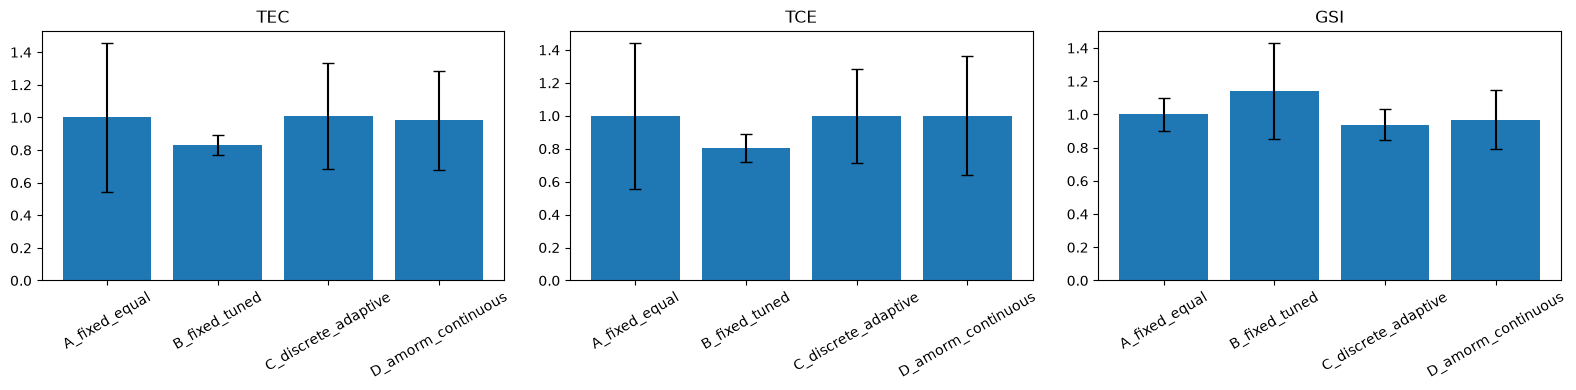

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ["TEC_mean", "TCE_mean", "GSI_mean"]):
    ax.bar(summary.index, summary[metric], yerr=summary[metric.replace("mean", "std")], capsize=4)
    ax.set_title(metric.replace("_mean", ""))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

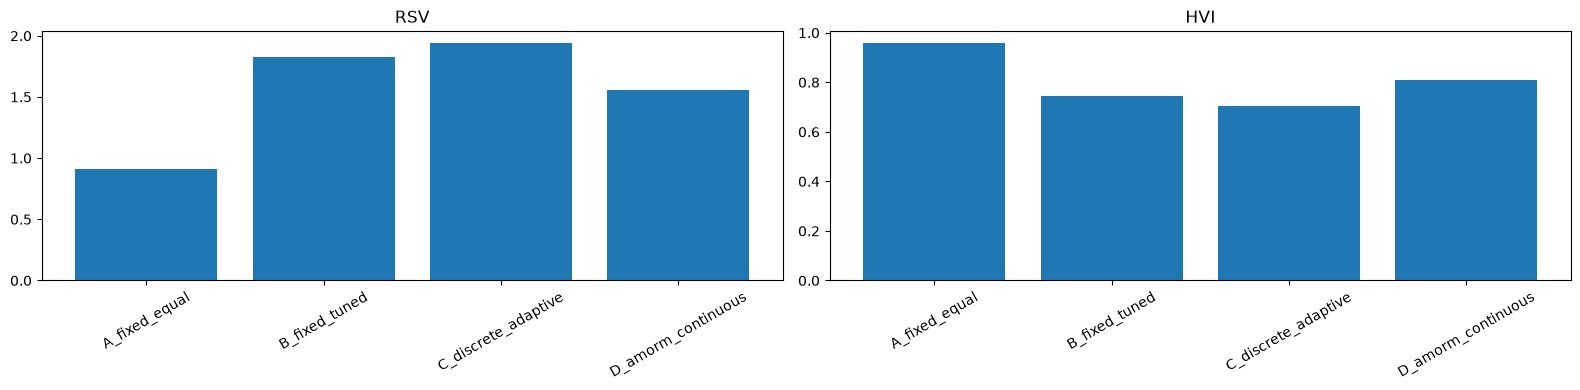

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric in zip(axes, ["RSV", "HVI"]):
    ax.bar(final_metrics.index, final_metrics[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
def get_target_weights(env):
    if env.operator_mode == env.operator_modes["sustainability"]:
        return TARGET_WEIGHTS["sustainability"]
    elif env.operator_mode == env.operator_modes["reliability"]:
        return TARGET_WEIGHTS["emergency"]
    L, G, P = get_grid_state_signals(env)
    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

In [ ]:
def run_human_override_episode(env, actors, weight_fn, switch_step=72, device="cpu"):
    obs, _ = env.reset()
    env.current_step = env.episode_start
    obs = env._get_observations()
    env.weights = np.array([0.6, 0.2, 0.2], dtype=np.float32)   # start: Economy Priority
    env.operator_mode = env.operator_modes["economy"]

    prev_L_holder = [None]
    history = []
    done = False
    step_index = 0

    while not done:
        if step_index == switch_step:
            env.operator_mode = env.operator_modes["sustainability"]
            print(f"Operator override applied at step {step_index}: Economy -> Sustainability")

        actions = {}
        for agent in env.possible_agents:
            obs_tensor = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
            dist = actors[agent](obs_tensor)
            actions[agent] = int(dist.probs.argmax().item())

        env.weights = weight_fn(env, env.weights, prev_L_smooth=prev_L_holder)

        next_obs, rewards, terminations, truncations, infos = env.step(actions)
        info = infos[env.possible_agents[0]]
        info["step"] = step_index
        info["weights"] = env.weights.copy()
        history.append(info)

        done = terminations[env.possible_agents[0]] or truncations[env.possible_agents[0]]
        obs = next_obs if not done else obs
        step_index += 1

    return pd.DataFrame(history)


config_d_result = next(r for r in all_results if r["config"] == "D_amorm_continuous" and r["seed"] == 0)
env = make_test_env()
actors_d = load_policy(config_d_result, env.possible_agents)

override_history = run_human_override_episode(env, actors_d, weights_config_D, switch_step=72)

Operator override applied at step 72: Economy -> Sustainability


In [ ]:
weights_over_time = np.stack(override_history["weights"].values)

target_w2 = 0.6
post_switch = weights_over_time[72:, 1]
within_tolerance = np.where(np.abs(post_switch - target_w2) < 0.05)[0]
adaptation_latency = within_tolerance[0] if len(within_tolerance) > 0 else None
print("Adaptation latency (steps):", adaptation_latency)

before = override_history.iloc[48:72][["cost_reward", "carbon_reward", "stability_reward"]].mean()
after = override_history.iloc[72:96][["cost_reward", "carbon_reward", "stability_reward"]].mean()
behavioral_shift = (after - before).round(4)
print("\nBehavioral shift (after - before):\n", behavioral_shift)

def action_change_rate(history_slice):
    changes = 0
    for col in ["building_a_demand", "building_b_demand"]:
        diffs = history_slice[col].diff().abs()
        changes += (diffs > diffs.median() * 2).sum()
    return changes

baseline_changes = action_change_rate(override_history.iloc[48:72])
transition_changes = action_change_rate(override_history.iloc[72:96])
print(f"\nErratic-change count — baseline: {baseline_changes}, transition window: {transition_changes}")

Adaptation latency (steps): 0

Behavioral shift (after - before):
 cost_reward        -0.0360
carbon_reward      -0.0288
stability_reward    0.0275
dtype: float64

Erratic-change count — baseline: 7, transition window: 6


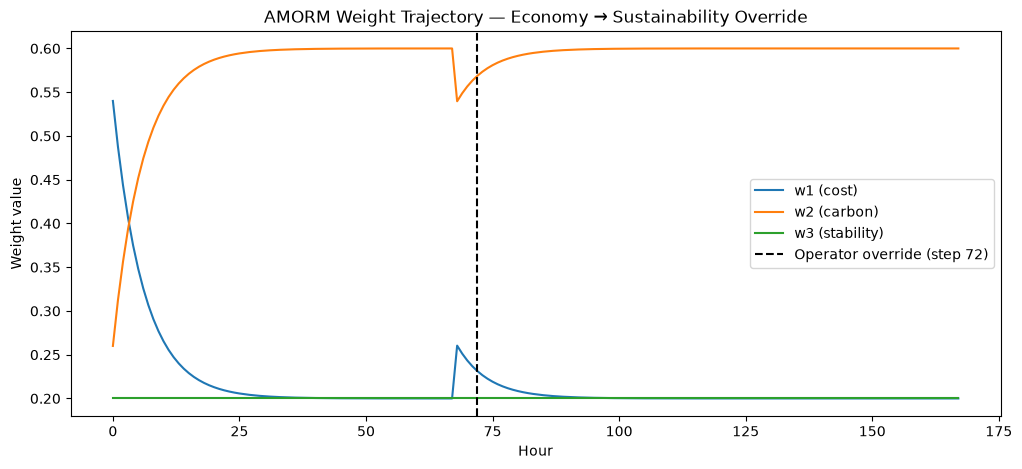

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
steps = override_history["step"].values
ax.plot(steps, weights_over_time[:, 0], label="w1 (cost)")
ax.plot(steps, weights_over_time[:, 1], label="w2 (carbon)")
ax.plot(steps, weights_over_time[:, 2], label="w3 (stability)")
ax.axvline(72, color="black", linestyle="--", label="Operator override (step 72)")
ax.set_xlabel("Hour")
ax.set_ylabel("Weight value")
ax.set_title("AMORM Weight Trajectory — Economy \u2192 Sustainability Override")
ax.legend()
plt.show()